In [1]:
%cd /home/dani/projects/neuroscience

/home/dani/projects/neuroscience


In [2]:
import torch
import torchsde
import matplotlib.pyplot as plt

from control.model import LinearControlSDE

In [5]:
def control_input(t, y):
    """
    Control law: Proportional-Derivative (PD) controller
    u = -Kp * x₁ - Kd * x₂
    (Targeting equilibrium at origin)
    """
    batch_size = y.shape[0]
    
    # PD gains
    Kp = 0.5
    Kd = 0.3
    
    # Extract position and velocity
    x1 = y[:, 0:1]  # position
    x2 = y[:, 1:2]  # velocity
    
    # PD control
    u = -Kp * x1 - Kd * x2
    
    return u

In [6]:
torch.manual_seed(1234)
    
# Initialize spring-mass-damper system
m, k, c = 1.0, 1.0, 0.5
A = torch.tensor([[0.0, 1.0],[-k/m, -c/m]])
B = torch.tensor([[0.0], [1.0/m]])

sde = LinearControlSDE(A, B, control_input=control_input, sigma=0.01)

# Initial condition: [position, velocity]
num_trajectories = 5
y0 = torch.tensor([2.0, 0.0]).repeat(num_trajectories, 1) + 0.1*torch.randn((num_trajectories,1))

# Time span
t_span = [0.0, 20.0]

# Simulate multiple trajectories
ts = torch.linspace(t_span[0], t_span[1], 100)
ys = torchsde.sdeint(sde, y0, ts, method="euler", dt_min=1e-1)

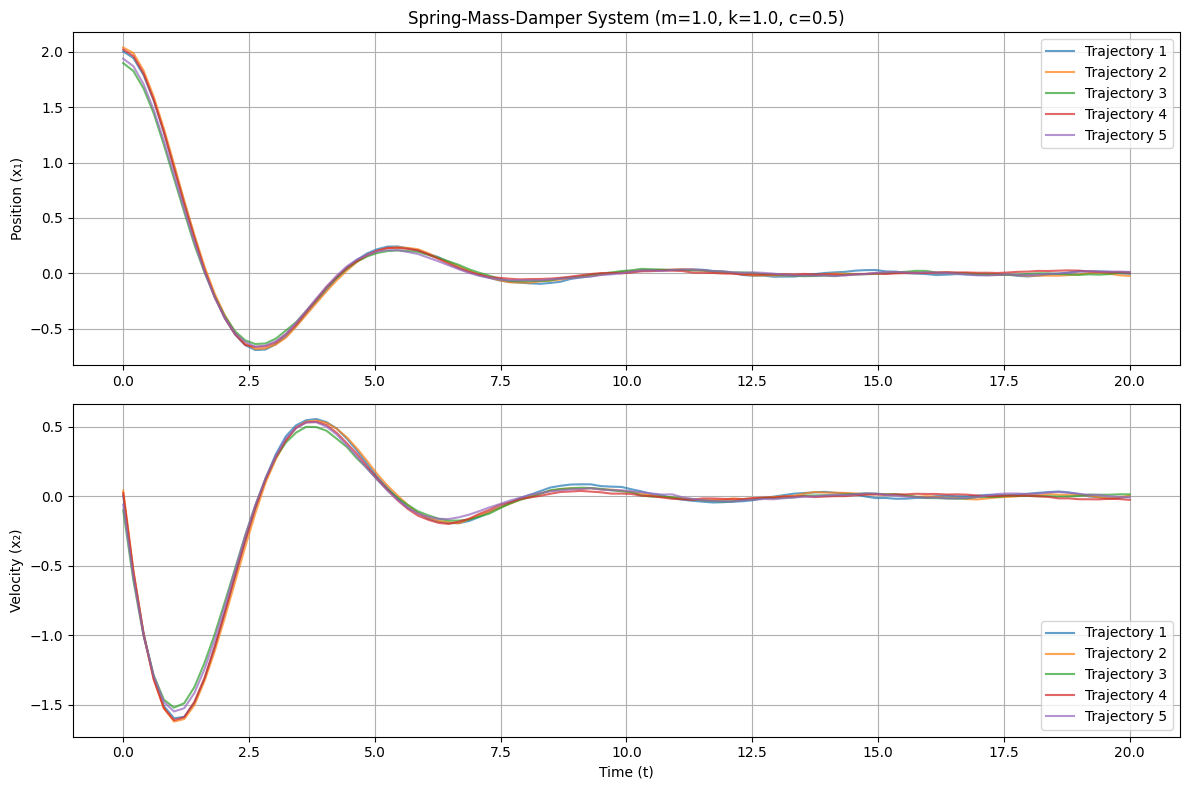

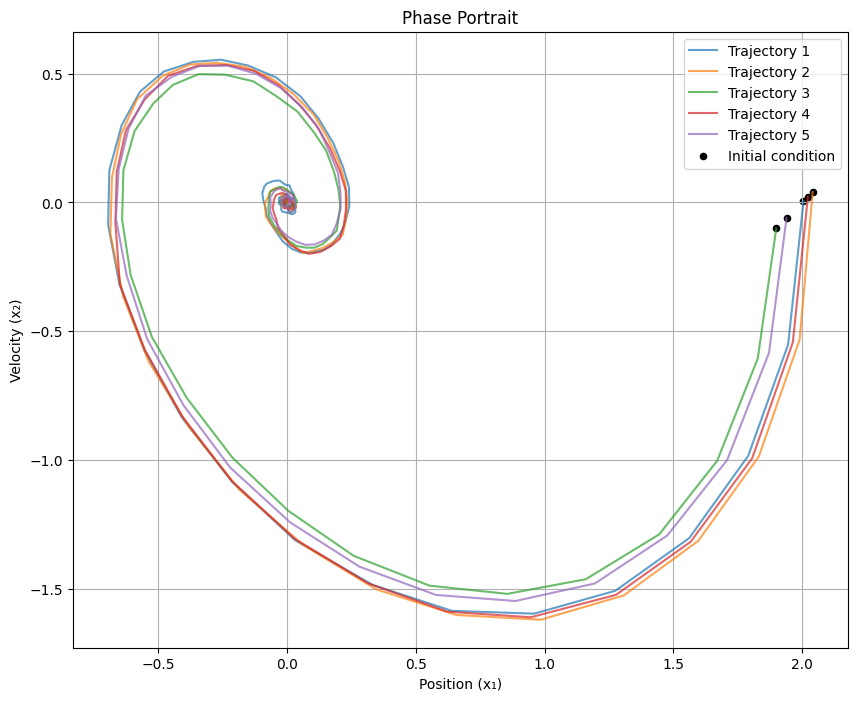

In [7]:
ts_np = ts.detach().numpy()
ys_np = ys.detach().numpy()

# Plot results
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Position
axes[0].set_title(f'Spring-Mass-Damper System (m={m}, k={k}, c={c})')
for i in range(num_trajectories):
    axes[0].plot(ts_np, ys_np[:, i, 0], alpha=0.7, label=f'Trajectory {i+1}')
axes[0].set_ylabel('Position (x₁)')
axes[0].grid(True)
axes[0].legend()

# Velocity
for i in range(num_trajectories):
    axes[1].plot(ts_np, ys_np[:, i, 1], alpha=0.7, label=f'Trajectory {i+1}')
axes[1].set_xlabel('Time (t)')
axes[1].set_ylabel('Velocity (x₂)')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.savefig('spring_mass_damper_sde.png', dpi=150, bbox_inches='tight')
plt.show()

# Phase portrait
plt.figure(figsize=(10, 8))
for i in range(num_trajectories):
    plt.plot(ys_np[:, i, 0], ys_np[:, i, 1], alpha=0.7, label=f'Trajectory {i+1}')
plt.scatter(y0[:,0].numpy(), y0[:,1].numpy(), s=20, c="k", label='Initial condition')
plt.xlabel('Position (x₁)')
plt.ylabel('Velocity (x₂)')
plt.title('Phase Portrait')
plt.grid(True)
plt.legend()
plt.savefig('phase_portrait_sde.png', dpi=150, bbox_inches='tight')
plt.show()

#print(f"Initial conditions: x₁={y0[0]:.2f}, x₂={y0[1]:.2f}")
#print(f"Final states (trajectory 1): x₁={ys_np[-1, 0, 0]:.4f}, x₂={ys_np[-1, 0, 1]:.4f}")
#print(f"\nSimulation completed with {num_trajectories} trajectories over t ∈ [{t_span[0]}, {t_span[1]}]")